# 01 - Veri Yükleme ve Kalite Analizi

Adım 1: transaction + identity birleştirme, eksik veri, otomatik kolon tipi, veri kalitesi, dağılımlar, yüksek cardinality.

Veri `python scripts/prepare_data.py` ile hazırlanır (`merged.parquet`, `schema.json`, `quality_report.json`).
Bu notebook aynı modülleri kullanarak bulguları gösterir.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fraud_platform.config import PROJECT_ROOT, get_settings
from fraud_platform.data.loader import DataLoader
from fraud_platform.data.profiler import numeric_summary, target_rate_by, top_categories
from fraud_platform.data.schema import Schema

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
IMG = PROJECT_ROOT / "docs" / "images"
IMG.mkdir(parents=True, exist_ok=True)

settings = get_settings()
ID, TARGET, AMT = settings.data.id_column, settings.data.target_column, settings.data.amount_column

df = DataLoader(settings).load()
schema = Schema.load(settings.schema_path)
report = json.loads(settings.quality_report_path.read_text(encoding="utf-8"))

## 1. Birleştirme

`train_transaction` (590.540 x 394) ile `train_identity` (144.233 x 41) `TransactionID` üzerinden left join ile birleştirildi.
Inner join identity bilgisi olmayan işlemleri atardı. `has_identity` bayrağı eklendi.

In [2]:
print("satır x kolon       :", df.shape)
print("TransactionID tekil :", df[ID].is_unique)
print("identity oranı      :", round(df["has_identity"].mean(), 4))
print(f"bellek              : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB (float64->float32 sonrası, önce 2.08 GB)")
print(f"fraud oranı         : {df[TARGET].mean():.4f}")

satır x kolon       : (590540, 435)
TransactionID tekil : True
identity oranı      : 0.2442
bellek              : 1.13 GB (float64->float32 sonrası, önce 2.08 GB)
fraud oranı         : 0.0350


> **Yorum:** Identity tablosu işlemlerin sadece %24,4'ünde var. Inner join yapsaydım işlemlerin dörtte üçünü kaybederdim; bu yüzden
> left join yaptım ve identity'nin olup olmadığını `has_identity` bayrağıyla tuttum. float64 kolonları float32'ye çevirerek
> belleği 2,08 GB'tan 1,13 GB'a indirdim; tutar kolonunda 3 ondalık hanede hiçbir değer değişmedi. Fraud oranı %3,5, veri çok
> dengesiz; bu yüzden accuracy yerine PR-AUC'ye ve sabit alarm bütçesindeki precision / recall'a bakacağım.

## 2. Otomatik kolon tipleri

`SchemaInferer` sırası: config rolleri (id, hedef, zaman) -> değer sayısı (sabit, binary) -> config override'ları
(Kaggle açıklamasındaki kategorik liste: `card1-6`, `addr1-2`, `id_12-38`) -> metin tipi -> sayısal.
Her kolonun hangi kuralla tiplendiği `reason` alanında.

In [3]:
sf = schema.to_frame()
sf["semantic_type"].value_counts()

semantic_type
numeric        375
categorical     31
binary          26
identifier       1
target           1
datetime         1
Name: count, dtype: int64

In [4]:
sf.groupby(["semantic_type", "reason"]).size().rename("kolon_sayısı").to_frame()

kolon_sayısı
semantic_type reason                             
binary        2 farklı değer                   26
categorical   metin tipi                        5
              override: addr[12]                2
              override: card[1-6]               6
              override: id_1[2-9]               6
              override: id_2[0-9]               7
              override: id_3[0-8]               5
datetime      config: time_column               1
identifier    config: id_column                 1
numeric       sayısal                         375
target        config: target_column             1

In [5]:
# sayısal saklanan ama override ile kategorik sayılan kolonlara örnek
sf.loc[["card1", "addr1", "C1", "D1", "M4", "DeviceInfo", "id_31"], ["semantic_type", "reason", "dtype", "n_unique", "cardinality"]]

,semantic_type,reason,dtype,n_unique,cardinality
name,,,,,
card1,categorical,override: card[1-6],int16,13553,high
addr1,categorical,override: addr[12],float32,332,high
C1,numeric,sayısal,float32,1657,NaN
D1,numeric,sayısal,float32,641,NaN
M4,categorical,metin tipi,str,3,low
DeviceInfo,categorical,metin tipi,str,1786,high
id_31,categorical,override: id_3[0-8],str,130,high


> **Yorum:** Tipi sadece pandas dtype'ına bakarak belirleyemedim. card1 tam sayı ama bir kart kodu, C1 de tam sayı ama bir sayaç; ikisi
> de çok farklı değerli olduğu için istatistikle ayırt edilemiyor. Bu yüzden önce kurallar (sabit, binary, metin tipi), sonra
> Kaggle açıklamasındaki kategorik listeyi config'ten override olarak uyguladım. Sonuç: 375 sayısal, 31 kategorik (13'ü yüksek
> cardinality), 26 binary. Her kolonun neden o tipi aldığı `reason` alanında yazıyor, şema kararları kontrol edilebiliyor.

## 3. Eksik veri

In [6]:
pd.Series(report["missing"]["groups"], name="kolon_sayısı").to_frame()

,kolon_sayısı
eksiksiz,21
az (<%20),162
orta (%20-50),38
çok (%50-90),202
neredeyse boş (>%90),12


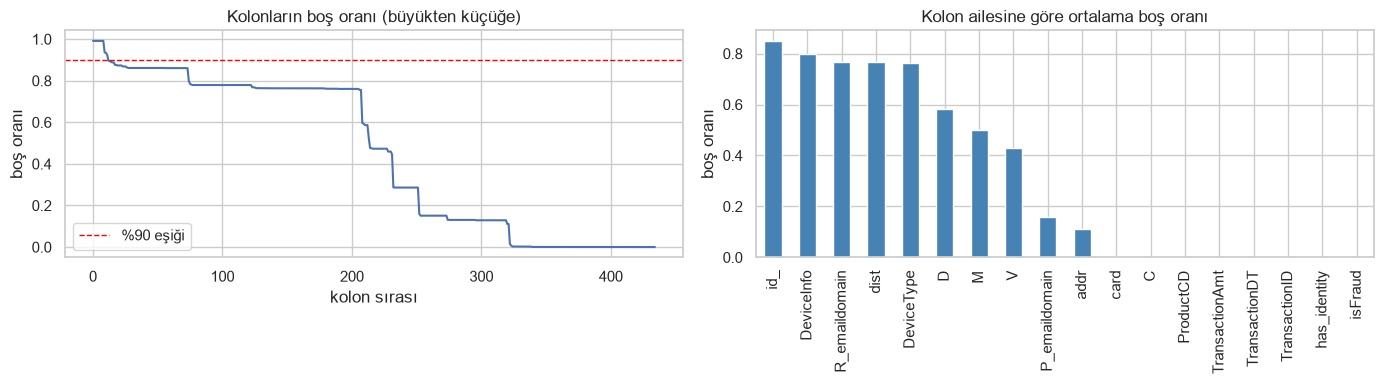

In [7]:
null_ratio = df.isna().mean().sort_values(ascending=False)
family = null_ratio.index.str.replace(r"\d+$", "", regex=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(len(null_ratio)), null_ratio.values)
axes[0].axhline(settings.quality.near_empty_null_ratio, color="red", ls="--", lw=1, label="%90 eşiği")
axes[0].set(title="Kolonların boş oranı (büyükten küçüğe)", xlabel="kolon sırası", ylabel="boş oranı")
axes[0].legend()

fam_null = null_ratio.groupby(family).mean().sort_values(ascending=False)
fam_null.plot.bar(ax=axes[1], color="steelblue")
axes[1].set(title="Kolon ailesine göre ortalama boş oranı", xlabel="", ylabel="boş oranı")
plt.tight_layout()
fig.savefig(IMG / "01_null_ratio.png", dpi=120)

In [8]:
print("%90'dan fazla boş:", report["missing"]["near_empty_columns"])

%90'dan fazla boş: ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'dist2', 'D7', 'id_18']


Blok halinde eksiklik: boşluk maskesi birebir aynı olan kolon grupları. Aynı satırlarda birlikte boş olmaları,
bu kolonların aynı kaynaktan / aynı koşulda üretildiğini düşündürüyor.

In [9]:
blocks = pd.DataFrame(report["missing"]["null_blocks"])
blocks["örnek_kolonlar"] = blocks["columns"].map(lambda c: ", ".join(c[:5]) + (" ..." if len(c) > 5 else ""))
print("blok sayısı:", len(blocks))
blocks[["null_ratio", "n_columns", "örnek_kolonlar"]].head(12)

blok sayısı: 26


,null_ratio,n_columns,örnek_kolonlar
0,0.7791,46,"V217, V218, V219, V223, V224 ..."
1,0.0005,43,"V95, V96, V97, V98, V99 ..."
2,0.0000,32,"V279, V280, V284, V285, V286 ..."
3,0.7636,31,"V167, V168, V172, V173, V176 ..."
4,0.1288,23,"V12, V13, V14, V15, V16 ..."
5,0.1306,22,"V53, V54, V55, V56, V57 ..."
6,0.1510,20,"V75, V76, V77, V78, V79 ..."
7,0.7632,19,"V169, V170, V171, V174, V175 ..."
8,0.2861,18,"V35, V36, V37, V38, V39 ..."
9,0.8612,18,"V138, V139, V140, V141, V142 ..."


> **Yorum:** Eksiklik çok fazla: 12 kolon %90'dan, 202 kolon %50-90 arası boş. Boş oranı grafiğindeki merdiven şekli kolonların gruplar
> halinde boş olduğunu gösteriyor. Boşluk maskesi birebir aynı 26 blok buldum; en büyüğünde 46 V kolonu işlemlerin %77,9'unda
> birlikte boş. Bu kolonlar büyük ihtimalle aynı kaynaktan geliyor, o yüzden her kolon için ayrı değil blok başına tek bir
> boşluk bayrağı yeterli. id_ ve DeviceInfo kolonlarının ~%76-80 boş olmasının sebebi identity'nin sadece işlemlerin %24'ünde olması.

## 4. Veri kalitesi

In [10]:
dup = report["duplicates"]
print("tekrar eden ID              :", dup["duplicate_ids"])
print("ID hariç tekrar eden satır  :", dup["duplicate_rows_excluding_id"])
print("birebir kopya kolon         :", dup["duplicate_columns"])
print("sabit kolon                 :", report["constant_columns"])
print("tutar <= 0                  :", report["invalid_values"]["non_positive_amount"])

tekrar eden ID              : 0
ID hariç tekrar eden satır  : 3
birebir kopya kolon         : []
sabit kolon                 : []
tutar <= 0                  : 0


In [11]:
# ID hariç birebir aynı satırlar
same = df[df.drop(columns=ID).duplicated(keep=False)]
same[[ID, TARGET, "TransactionDT", AMT, "ProductCD", "card1", "addr1", "P_emaildomain"]].sort_values("TransactionDT")

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,addr1,P_emaildomain
295456,3282456,0,7310775,47.950001,W,7919,191.0,gmail.com
295457,3282457,0,7310775,47.950001,W,7919,191.0,gmail.com
453414,3440414,0,11576951,512.950012,W,1359,299.0,NaN
453415,3440415,0,11576951,512.950012,W,1359,299.0,NaN
570433,3557433,0,15129302,44.000000,W,2744,205.0,NaN
570434,3557434,0,15129302,44.000000,W,2744,205.0,NaN


In [12]:
# negatif değer içeren sayısal kolonlar (D kolonları gün farkı olduğu için negatif olmamalı)
pd.Series(report["invalid_values"]["negative_value_columns"], name="negatif_satır").to_frame()

,negatif_satır
id_01,124678
id_06,45540
id_05,6097
id_08,4894
id_10,2047
id_04,585
id_09,463
id_07,347
id_03,187
D4,15


In [13]:
# yazım farkları
print("büyük/küçük harf farkı:")
for col, groups in report["text_issues"]["case_variants"].items():
    print(f"  {col}: {list(groups.values())}")
print("\naynı kök domain, farklı yazım (P_emaildomain):")
for root, values in report["text_issues"]["domain_variants"]["P_emaildomain"].items():
    print(f"  {root}: {values}")
print("\nsayı olup metin saklanan kolon:", report["text_issues"]["numeric_stored_as_text"])

büyük/küçük harf farkı:
  DeviceInfo: [['ALCATEL', 'Alcatel'], ['DASH', 'Dash'], ['ILIUM', 'Ilium'], ['MI', 'Mi'], ['Moto', 'moto'], ['STELLAR', 'Stellar'], ['Vivo', 'vivo']]

aynı kök domain, farklı yazım (P_emaildomain):
  gmail: ['gmail', 'gmail.com']
  hotmail: ['hotmail.co.uk', 'hotmail.com', 'hotmail.de', 'hotmail.es', 'hotmail.fr']
  live: ['live.com', 'live.com.mx', 'live.fr']
  netzero: ['netzero.com', 'netzero.net']
  outlook: ['outlook.com', 'outlook.es']
  yahoo: ['yahoo.co.jp', 'yahoo.co.uk', 'yahoo.com', 'yahoo.com.mx', 'yahoo.de', 'yahoo.es', 'yahoo.fr']

sayı olup metin saklanan kolon: []


> **Yorum:** Tekrar eden ID, sabit kolon, kopya kolon ve sıfır/negatif tutar yok. ID dışında aynı 3 çift satır var (ardışık ID, aynı
> saniye): çift gönderim gibi duruyor, raporladım ama silmedim. D4, D11 ve D15'te birkaç negatif değer var; gün farkı negatif
> olamayacağı için Adım 3'te 0'a kırptım. id_ kolonlarındaki negatifleri hata saymadım, anlamları anonim ve çok sayıdalar.
> DeviceInfo'da büyük/küçük harf farkları (Moto/moto), e-postada gmail/gmail.com gibi yazım farkları var; Adım 3'te temizledim.

## 5. Dağılımlar

In [14]:
num_cols = schema.of_type("numeric")
ns = numeric_summary(df, num_cols)
print(f"log dönüşüm adayı (skew > 2 ve min >= 0): {ns['log_candidate'].sum()} / {len(ns)} sayısal kolon")
ns.loc[[AMT, "C1", "C13", "D1", "D15", "dist1"]].round(2)

log dönüşüm adayı (skew > 2 ve min >= 0): 322 / 375 sayısal kolon


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,log_candidate
TransactionAmt,590540.0,135.03,239.16,0.25,43.32,68.77,125.0,31937.39,14.370000,1123.959961,True
C1,590540.0,14.09,133.57,0.00,1.00,1.00,3.0,4685.00,23.959999,669.380005,True
C13,590540.0,32.54,129.36,0.00,1.00,3.00,12.0,2918.00,8.990000,127.050003,True
D1,589271.0,94.35,157.66,0.00,0.00,3.00,122.0,640.00,1.810000,2.200000,False
D15,501427.0,163.74,202.73,-83.00,0.00,52.00,314.0,879.00,0.960000,-0.530000,False
dist1,238269.0,118.50,371.87,0.00,3.00,8.00,24.0,10286.00,5.110000,36.799999,True


çarpıklık ham  : 14.37
çarpıklık log1p: 0.49
medyan tutar   : {0: 68.5, 1: 75.0}


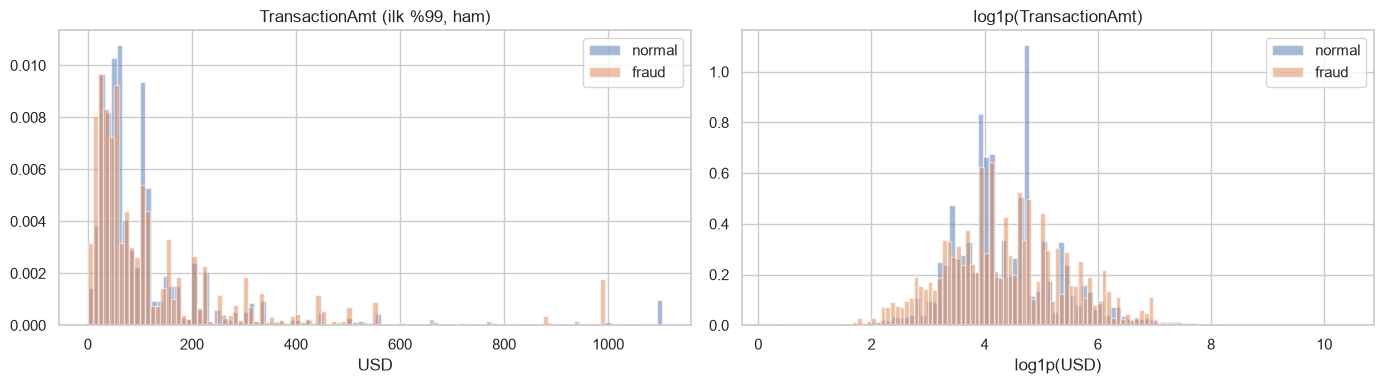

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, name in [(0, "normal"), (1, "fraud")]:
    s = df.loc[df[TARGET] == label, AMT]
    axes[0].hist(s.clip(upper=s.quantile(0.99)), bins=100, alpha=0.5, density=True, label=name)
    axes[1].hist(np.log1p(s), bins=100, alpha=0.5, density=True, label=name)
axes[0].set(title=f"{AMT} (ilk %99, ham)", xlabel="USD")
axes[1].set(title=f"log1p({AMT})", xlabel="log1p(USD)")
for ax in axes:
    ax.legend()
plt.tight_layout()
fig.savefig(IMG / "01_amount_distribution.png", dpi=120)

print("çarpıklık ham  :", round(df[AMT].skew(), 2))
print("çarpıklık log1p:", round(np.log1p(df[AMT]).skew(), 2))
print("medyan tutar   :", df.groupby(TARGET)[AMT].median().to_dict())

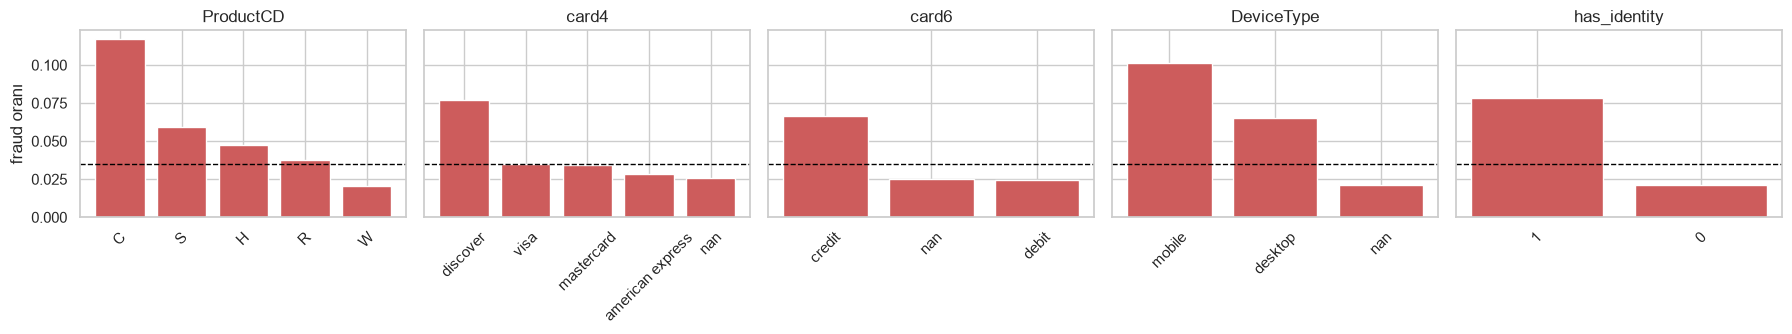

In [16]:
cats = ["ProductCD", "card4", "card6", "DeviceType", "has_identity"]
fig, axes = plt.subplots(1, len(cats), figsize=(18, 3.5), sharey=True)
for ax, col in zip(axes, cats):
    t = target_rate_by(df, col, TARGET, min_count=100)
    ax.bar([str(v) for v in t.index], t["rate"], color="indianred")  # pandas 3: astype(str) NaN'ı korur
    ax.axhline(df[TARGET].mean(), color="black", ls="--", lw=1)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("fraud oranı")
plt.tight_layout()
fig.savefig(IMG / "01_fraud_rate_by_category.png", dpi=120)

In [17]:
target_rate_by(df, "ProductCD", TARGET).round(4)

,count,rate,share,lift
ProductCD,,,,
C,68519,0.1169,0.1160,3.3402
S,11628,0.0590,0.0197,1.6861
H,33024,0.0477,0.0559,1.3622
R,37699,0.0378,0.0638,1.0810
W,439670,0.0204,0.7445,0.5830


In [18]:
low_card = [c.name for c in schema.columns.values() if c.cardinality == "low"]
top_categories(df, low_card, k=3)

,column,value,share
0,ProductCD,W,0.7445
1,ProductCD,C,0.1160
2,ProductCD,R,0.0638
3,card4,visa,0.6516
4,card4,mastercard,0.3204
5,card4,american express,0.0141
6,card6,debit,0.7450
7,card6,credit,0.2523
8,card6,NaN,0.0027
9,M4,NaN,0.4766


> **Yorum:** Tutar çok sağa çarpık (skew 14,4); log1p sonrası 0,49'a iniyor, modellerde log tutar kullandım. Fraud ve normal işlemlerin
> medyan tutarı yakın (75 vs 68,5), yani tutar tek başına güçlü bir sinyal değil. Kategorilerde fark büyük: ProductCD=C'de
> fraud %11,7 (ortalamanın 3,3 katı), W'de %2,0; kredi kartında %6,7, banka kartında %2,4; discover %7,7; mobil cihazda %10,2.
> Bunları Adım 6'da context kuralı adayı olarak test ettim (kredi kartı kural oldu, ürün C'yi skor zaten yakaladığı için kapattım).
> 375 sayısal kolonun 322'si çarpık; aykırı değer tespitinde ortalama/std yerine medyan/MAD gibi robust yöntemleri bu yüzden seçtim.

## 6. Yüksek cardinality

In [19]:
hc = pd.DataFrame(report["high_cardinality"]).set_index("column")
hc

,n_unique,null_ratio,suggested_encoding
column,,,
card1,13553,0.000000,frequency encoding + nadir değerleri 'other' a...
DeviceInfo,1786,0.799055,frequency encoding + nadir değerleri 'other' a...
id_19,522,0.764084,frequency encoding + nadir değerleri 'other' a...
card2,500,0.015127,frequency encoding + nadir değerleri 'other' a...
id_21,490,0.991264,frequency encoding + nadir değerleri 'other' a...
id_20,394,0.764180,frequency encoding + nadir değerleri 'other' a...
id_25,341,0.991310,frequency encoding + nadir değerleri 'other' a...
addr1,332,0.111264,frequency encoding + nadir değerleri 'other' a...
id_33,260,0.875895,frequency encoding + nadir değerleri 'other' a...


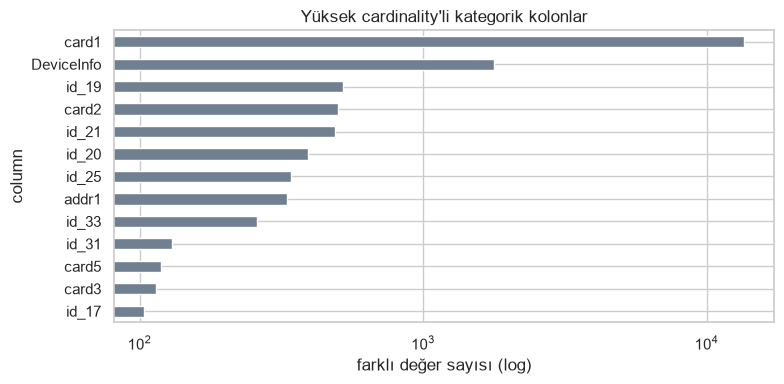

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
hc["n_unique"].sort_values().plot.barh(ax=ax, logx=True, color="slategray")
ax.set(title="Yüksek cardinality'li kategorik kolonlar", xlabel="farklı değer sayısı (log)")
plt.tight_layout()
fig.savefig(IMG / "01_high_cardinality.png", dpi=120)

> **Yorum:** 13 kategorik kolonun 100'den fazla farklı değeri var (card1 13.553, DeviceInfo 1.786). One-hot bu kolonlarda binlerce kolon
> üretirdi; bunun yerine frekans kodlaması kullandım (Adım 3'te card1, card2, card5, addr1, e-posta domainleri, DeviceInfo,
> id_31, id_33 için `_freq` feature'ları). Column dedektöründe de kategorik değerin nadirliği frekanstan hesaplanıyor.
> card1 ve addr1'i ayrıca doğrudan feature olarak değil, kullanıcı tanımının (uid) parçası olarak kullandım.

## 7. Özet

Üretilen çıktılar: `data/processed/merged.parquet`, `artifacts/schema.json`, `artifacts/quality_report.json`, `docs/images/01_*.png`

Bulgular ve sonraki adımlara etkisi

1. Identity sadece işlemlerin %24,4'ünde -> left join + `has_identity`. Boş olmanın kendisi sinyal; Adım 2'de ölçtüm, Adım 3'te bayrak yaptım.
2. Kolon tipini istatistik tek başına çözemiyor -> config override'lı şema. Başka bir veri setinde sadece config değişir.
3. Eksiklik bloklar halinde -> blok başına tek boşluk bayrağı (M1, M4, M6, M7 gibi).
4. Tutar çarpık ve tek başına zayıf -> log tutar; kişisel tutar sapmasını Adım 3'te ayrıca ölçtüm, orada da zayıf çıktı.
5. Ürün, kart tipi, cihaz tipi ve identity varlığı fraud oranını belirgin değiştiriyor -> Adım 6'da context kuralı adayları.